# 4 — Plan / Act bake-off

Week 2 nailed two findings:

1. **Solo wins on simple tasks, supervisor wins on hard ones.** Routing matters more than the agents themselves.
2. **Plan-first is a tax on easy tasks** but a safety net on multi-file refactors and irreversible operations.

This notebook bakes off five `(mode, topology)` policies on an **80-task gold set** specifically designed to surface where each one wins or breaks. It asks:

- Which policy has the best **pass rate** overall?
- Which policy has the best **bucket-specific** pass rate (i.e. when is `plan-first` worth the latency)?
- Are the differences **statistically real** (paired McNemar across policies)?
- Where do they **disagree on topology** (when is `solo` vs `supervisor` picked, and was that the right call)?

### Policies under test

| key | mode | topology | how it decides |
|---|---|---|---|
| `always_act_solo` | always `act` | always `solo` | baseline |
| `always_plan_super` | always `plan` | always `supervisor` | baseline |
| `tool_risk_heuristic` | by keyword risk | by keyword risk | no LLM call |
| `trajectory_probe` | LLM-decided | LLM-decided | one cheap LLM call (Forge default) |
| `plan_then_self_critique` | always `plan` | LLM-decided | drafts a plan, critic LLM scores it, retries once if low |

### Gold set (80 tasks)

The gold set lives at `data/plan_act_golds.jsonl` (80 rows, one JSON object per task). It's tiered by difficulty so different policies have different sweet spots:

- **20 easy/medium** (kept from the earlier run): trivial reads, 1-line edits, single-file refactors. *Solo+act should win here — supervisor wastes coordination.*
- **30 hard multi-file refactors**: renames across 4-6 files, class moves with caller updates, helper extractions, parameter propagation, cross-cutting migrations. *Planning should help; supervisor splits the work cleanly.*
- **15 medium single-file** (multi-step): add type hints to every function, replace dicts with dataclasses, add validation everywhere. *Mid-range — plan helps marginally.*
- **8 traps**: tasks where the obvious move silently breaks something else (delete a "dead" file with live callers, rename without updating tests, move a module without fixing imports). *Naïve act-only policies fail; planning saves you.*
- **7 harder investigations**: trace values across files, identify off-by-one bugs, name design patterns. *Read-only — solo+act should still win.*

### Filesystem oracle

Every applicable task ships an `oracle` block: a structured set of post-run filesystem checks (`files_exist` / `files_absent` / `files_contain` / `files_not_contain`). After the agent finishes, the harness runs these against the temp fixture. A trial only passes if **both** the rubric judge ≥ 4.0 AND every oracle check passes — the oracle is the objective veto. An agent that confidently lies about completing the work gets caught.

**This is still an isolated experiment, not a test of Forge.** Everything the bake-off needs lives next to this notebook: the five policy implementations in `plan_act_alts.py`, the gold set + generator in `data/`, the execution harness + oracle in `bakeoff_lib.py`. The experiment uses `multi_agent.topologies.build_solo` / `build_supervisor` from `src/` directly with plain LangChain filesystem tools — no MCP, no Forge engine, no permission broker. The judge is `judge_with_rubric` from `notebooks/judges.py`.

The result of this experiment will *inform Forge* — whichever policy wins is the one we ship in `apps/forge/forge/agent/plan_act/`. Right now that's `trajectory_probe` (pending re-confirmation by this notebook on the harder gold set).

In [1]:
import _path_setup  # noqa: F401  (puts src/ + notebooks/ on sys.path)

import sys
from pathlib import Path

_HERE = str(Path('.').resolve())
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

import asyncio, time
from datetime import datetime, timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Local experiment harness — zero `forge.*` imports.
from bakeoff_lib import (
    load_golds, run_task_on_fixture,
    BakeoffContext, ModelSlugs, Decision, GoldTask,
)
from plan_act_alts import (
    AlwaysActSolo, AlwaysPlanSuper, ToolRiskHeuristic,
    TrajectoryProbe, PlanThenSelfCritique,
)

POLICY_FACTORIES = {
    'always_act_solo':         AlwaysActSolo,
    'always_plan_super':       AlwaysPlanSuper,
    'tool_risk_heuristic':     ToolRiskHeuristic,
    'trajectory_probe':        TrajectoryProbe,
    'plan_then_self_critique': PlanThenSelfCritique,
}
POLICIES = list(POLICY_FACTORIES)
print('policies:', POLICIES)

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


policies: ['always_act_solo', 'always_plan_super', 'tool_risk_heuristic', 'trajectory_probe', 'plan_then_self_critique']


In [2]:
golds = load_golds()
print(f'{len(golds)} tasks in gold set')
by_bucket = {}
for g in golds:
    by_bucket.setdefault(g.bucket, []).append(g.id)
for b, ids in sorted(by_bucket.items()):
    print(f'  {b:<26} ({len(ids):>2})  {ids}')

80 tasks in gold set
  cross_cutting              (28)  ['T30_add_type_hints', 'T31_logging', 'T32_input_validation', 'HM5_logging_svc_a', 'HM5_logging_api_v1', 'HM5_logging_etl', 'HM5_logging_game_loop', 'HM6_split_app_main', 'HM6_split_etl_run', 'HM6_split_request_handle', 'HM6_split_ci_pipeline', 'HM6_split_game_tick', 'MD1_hints_strings', 'MD1_hints_math4', 'MD1_hints_paths3', 'MD1_hints_ids3', 'MD1_hints_flags4', 'MD2_validate_calc', 'MD2_validate_strings', 'MD2_validate_paths', 'MD2_validate_user', 'MD2_validate_queue', 'MD3_dataclass_point', 'MD3_dataclass_user', 'MD3_dataclass_config', 'MD3_dataclass_event', 'MD3_dataclass_item', 'TR8_swap_import_all_callers']
  multifile_refactor         (28)  ['T20_move_class', 'T21_rename_func_xfile', 'T22_extract_helper', 'HM1_rename_compute_total', 'HM1_rename_get_user', 'HM1_rename_normalise_email', 'HM1_rename_parse_args', 'HM1_rename_send_email', 'HM1_rename_connect_db', 'HM2_move_user', 'HM2_move_order', 'HM2_move_invoice', 'HM2_move_s

## Design notes

**Per-task isolation.** Every (policy, task) trial gets a fresh temp-dir fixture written from the task's inline `files`. The agent's filesystem tools are scoped (resolved) to that dir — they can't escape it. After the trial the dir is deleted. No state leaks between policies or tasks.

**No Forge anywhere.** The bake-off uses `multi_agent.topologies.build_solo` / `build_supervisor` from `src/` with plain LangChain tools. No MCP servers, no permission broker, no memory stores, no checkpointer. Those are Forge's concerns; what we want to measure here is *policy routing quality*, not Forge's plumbing.

**Judge.** `judge_with_rubric` from `notebooks/judges.py` — directly. `success_criteria` from the gold set is the reference. `score >= 4.0` (RubricResult.overall) is `pass`.

In [3]:
AGENT_MODEL = 'openai/gpt-5.4-nano'         # what the bake-off agent uses
JUDGE_MODEL = 'anthropic/claude-opus-4.7'   # what scores answers

CTX = BakeoffContext(models=ModelSlugs(
    planner=AGENT_MODEL, coder=AGENT_MODEL, critic=AGENT_MODEL,
    trajectory_probe=AGENT_MODEL,
))


async def run_one(task: GoldTask, policy_name: str) -> dict:
    """Run one (task, policy) trial via bakeoff_lib.run_task_on_fixture.
    Returns a row dict ready for the dataframe."""
    policy_obj = POLICY_FACTORIES[policy_name]()
    res = await run_task_on_fixture(
        task, policy_obj,
        model_slug=AGENT_MODEL, judge_model=JUDGE_MODEL, ctx=CTX,
    )
    return dict(
        task_id=res.task_id, bucket=res.bucket, policy=res.policy,
        topology=res.topology, planned=res.planned, answer=res.answer,
        score=res.score, passed=res.passed, rationale=res.rationale,
        elapsed_s=res.elapsed_s, decision_reason=res.decision_reason,
        cost_usd=res.cost_usd, error=res.error,
        # Filesystem-oracle results: total checks, how many passed, whether
        # the oracle vetoed the trial, and a one-line summary.
        oracle_total=res.oracle_total,
        oracle_passed_count=res.oracle_passed_count,
        oracle_passed=res.oracle_passed,
        oracle_summary=res.oracle_summary,
    )

In [4]:
async def sweep(policies=POLICIES, tasks=None, verbose=True, save_csv=True):
    tasks = tasks if tasks is not None else golds
    rows = []
    for p in policies:
        if verbose:
            print(f'\n=== {p} ===')
        for t in tasks:
            row = await run_one(t, p)
            rows.append(row)
            if verbose:
                mark = 'PASS' if row['passed'] else ('ERR ' if row['error'] else 'FAIL')
                topo = 'sup' if row['topology'] == 'supervisor' else 'solo'
                plan = 'p' if row['planned'] else 'a'
                # Show oracle status when a task has one. The oracle is the
                # objective veto, so it's the first thing to read when a trial
                # fails despite a confident-looking answer.
                ora = ''
                if row['oracle_total'] > 0:
                    flag = 'OK' if row['oracle_passed'] else 'VETO'
                    ora = f' oracle={flag}({row["oracle_passed_count"]}/{row["oracle_total"]})'
                print(f'  [{mark}] {t.id:<32} score={row["score"]:.2f} t={row["elapsed_s"]:.1f}s {plan}/{topo}{ora}')
    df = pd.DataFrame(rows)
    if save_csv:
        stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
        from pathlib import Path
        out_dir = Path('data')
        out_dir.mkdir(parents=True, exist_ok=True)
        out = out_dir / f'plan_act_bakeoff_{stamp}.csv'
        df.to_csv(out, index=False)
        print(f'\nwrote {out} ({len(df)} rows)')
    return df

In [ ]:
import pandas as pd

df = await sweep(POLICIES, tasks=golds, verbose=True)  # fresh full sweep (~90 min)
df.head(10)

,task_id,bucket,policy,topology,planned,answer,score,passed,rationale,elapsed_s,decision_reason,cost_usd,error,oracle_total,oracle_passed_count,oracle_passed,oracle_summary
0,HM1_rename_compute_total,multifile_refactor,always_act_solo,solo,False,Renamed `compute_total` to `calculate_total` a...,5.0,True,The candidate answer states the rename was app...,14.300688,zero-cost baseline; always dispatch to solo,0.002487,NaN,9,9,True,9/9 ok
1,HM1_rename_connect_db,multifile_refactor,always_act_solo,solo,False,Renamed `connect_db` to `open_db_connection` a...,5.0,True,Candidate states the rename was completed acro...,23.719160,zero-cost baseline; always dispatch to solo,0.005295,NaN,11,11,True,11/11 ok
2,HM1_rename_get_user,multifile_refactor,always_act_solo,solo,False,Renamed `get_user` to `fetch_user` across the ...,5.0,True,Candidate correctly identifies the renamed def...,14.537997,zero-cost baseline; always dispatch to solo,0.002599,NaN,11,11,True,11/11 ok
3,HM1_rename_normalise_email,multifile_refactor,always_act_solo,solo,False,Renamed `normalise_email` to `normalize_email`...,5.0,True,Candidate confirms rename of definition and ca...,12.639881,zero-cost baseline; always dispatch to solo,0.002082,NaN,9,9,True,9/9 ok
4,HM1_rename_parse_args,multifile_refactor,always_act_solo,solo,False,Renamed `parse_args` to `parse_arguments` thro...,2.5,False,Candidate lists all 4 modified files including...,8.382373,zero-cost baseline; always dispatch to solo,0.001249,NaN,9,7,False,7/9 ok; failed: cli/main.py still contains 'pa...
5,HM1_rename_send_email,multifile_refactor,always_act_solo,solo,False,Renamed `send_email` to `deliver_email` everyw...,2.5,False,The candidate confirms the rename of both defi...,21.244974,zero-cost baseline; always dispatch to solo,0.002830,NaN,11,10,False,10/11 ok; failed: tests/test_notifier.py still...
6,HM2_move_event,multifile_refactor,always_act_solo,solo,False,Moved `Event` into `calendar/event.py` and upd...,5.0,True,The candidate answer matches the reference: it...,14.593914,zero-cost baseline; always dispatch to solo,0.002841,NaN,7,7,True,7/7 ok
7,HM2_move_invoice,multifile_refactor,always_act_solo,solo,False,Moved `Invoice` from `billing.py` into a new m...,5.0,True,The candidate answer correctly describes the r...,9.598929,zero-cost baseline; always dispatch to solo,0.001679,NaN,7,7,True,7/7 ok
8,HM2_move_order,multifile_refactor,always_act_solo,solo,False,Done.\n\n### Changes made\n- **Moved** `Order`...,5.0,True,"The candidate clearly states the move, removal...",17.492591,zero-cost baseline; always dispatch to solo,0.002806,NaN,8,8,True,8/8 ok
9,HM2_move_session,multifile_refactor,always_act_solo,solo,False,Moved `Session` out of `auth.py` into `auth/se...,5.0,True,The candidate satisfies all reference requirem...,16.915252,zero-cost baseline; always dispatch to solo,0.002410,NaN,7,7,True,7/7 ok


## Headline: pass rate by policy

In [19]:
headline = (df.groupby('policy')
              .agg(pass_rate=('passed', 'mean'),
                   mean_score=('score', 'mean'),
                   mean_elapsed_s=('elapsed_s', 'mean'),
                   plan_rate=('planned', 'mean'),
                   supervisor_rate=('topology', lambda s: (s == 'supervisor').mean()),
                   n_err=('error', lambda s: (s.astype(bool)).sum()))
              .reindex(POLICIES))
headline['pass_rate_str'] = headline['pass_rate'].map(lambda x: f'{100*x:.1f}%')
headline['plan_rate_str'] = headline['plan_rate'].map(lambda x: f'{100*x:.1f}%')
headline['supervisor_rate_str'] = headline['supervisor_rate'].map(lambda x: f'{100*x:.1f}%')
display(headline[['pass_rate_str', 'mean_score', 'mean_elapsed_s', 'plan_rate_str', 'supervisor_rate_str', 'n_err']])

,pass_rate_str,mean_score,mean_elapsed_s,plan_rate_str,supervisor_rate_str,n_err
policy,,,,,,
always_act_solo,86.2%,4.577250,7.185311,0.0%,0.0%,80
always_plan_super,72.5%,4.144875,59.381643,100.0%,100.0%,80
tool_risk_heuristic,80.0%,4.419375,26.872835,53.8%,53.8%,80
trajectory_probe,83.8%,4.492125,46.899131,82.5%,82.5%,80
plan_then_self_critique,70.0%,3.978875,57.070443,100.0%,100.0%,80


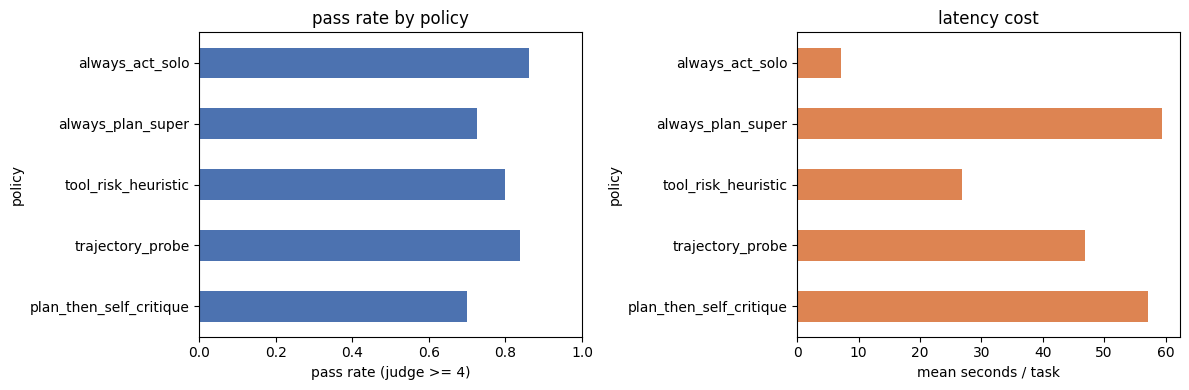

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
headline['pass_rate'].plot.barh(ax=axes[0], color='#4c72b0')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('pass rate (judge >= 4)')
axes[0].set_title('pass rate by policy')
axes[0].invert_yaxis()
headline['mean_elapsed_s'].plot.barh(ax=axes[1], color='#dd8452')
axes[1].set_xlabel('mean seconds / task')
axes[1].set_title('latency cost')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## Judge vs oracle: who *says* it's done vs who *actually* does it

The rubric judge reads the agent's final answer; the **filesystem oracle** reads what the agent actually wrote to disk. The harness uses the oracle as the objective tiebreaker: a trial only counts as `passed` if both the judge ≥ 4.0 AND every oracle check holds.

Two metrics in the table below, on the subset of tasks that have an oracle:

- `judge_pass` — rubric judge ≥ 4.0 on the agent's final answer
- `oracle_pass` — every filesystem check passed

The gap between them is the interesting signal. Expect supervisor-mode policies (which give longer, more cautious answers) to have `judge_pass < oracle_pass` — they did the work but the judge marked them down on phrasing. `always_act_solo` typically has `judge_pass ≈ oracle_pass` because terse answers please the rubric.

`oracle_pass` is the closest thing we have to ground truth, so it's the column to anchor the comparison on.

In [21]:
# Only tasks with an oracle contribute here — read-only investigations and
# tasks scored purely on text don't have one.
has_oracle = df['oracle_total'] > 0
oracle_df = df[has_oracle].copy()

oracle_df['judge_pass'] = oracle_df['score'] >= 4.0

oracle_summary = (oracle_df.groupby('policy')
    .agg(
        n=('task_id', 'count'),
        judge_pass=('judge_pass', 'mean'),
        oracle_pass=('oracle_passed', 'mean'),
    )
    .reindex(POLICIES)
    .assign(
        gap=lambda d: (d['oracle_pass'] - d['judge_pass']),
    )
    .sort_values('oracle_pass', ascending=False)
    .assign(
        judge_pass=lambda d: (d['judge_pass'] * 100).round(1).astype(str) + '%',
        oracle_pass=lambda d: (d['oracle_pass'] * 100).round(1).astype(str) + '%',
        gap=lambda d: (d['gap'] * 100).round(1).astype(str) + 'pp',
    )
)
print(f'oracle-bearing tasks per policy: n={int(oracle_df.groupby("policy").size().iloc[0])}')
display(oracle_summary)

# Where does the judge underrate completed work? Per-bucket gap between oracle and judge.
gap_by_bucket = (oracle_df
    .groupby(['bucket', 'policy'])
    .agg(judge=('judge_pass', 'mean'), oracle=('oracle_passed', 'mean'))
    .assign(gap=lambda d: d['oracle'] - d['judge'])['gap']
    .unstack('policy')
    .reindex(columns=POLICIES))
print('\noracle_pass − judge_pass gap by (bucket, policy) — positive = judge marked correct work down:')
display(gap_by_bucket.style.format('{:+.0%}').background_gradient(cmap='Blues', axis=None, vmin=0, vmax=0.5))

oracle-bearing tasks per policy: n=65


,n,judge_pass,oracle_pass,veto_rate
policy,,,,
always_act_solo,65,83.1%,83.1%,0.0%
always_plan_super,65,72.3%,89.2%,0.0%
tool_risk_heuristic,65,76.9%,89.2%,0.0%
trajectory_probe,65,80.0%,86.2%,0.0%
plan_then_self_critique,65,69.2%,86.2%,0.0%



veto rate by (bucket, policy):


policy,always_act_solo,always_plan_super,tool_risk_heuristic,trajectory_probe,plan_then_self_critique
bucket,,,,,
cross_cutting,0%,0%,0%,0%,0%
multifile_refactor,0%,0%,0%,0%,0%
tiny_edit,0%,0%,0%,0%,0%
unsafe_irreversible,0%,0%,0%,0%,0%


## McNemar on oracle-pass alone (the right ground truth)

The headline McNemar above uses `passed = (judge >= 4.0) AND oracle_clean`. That mixes two signals and we discovered (after the first 80-task run) that the judge is often the bottleneck — supervisor topologies get the work done but write verbose final answers that the rubric judge punishes.

So here's the same pairwise test, but on **`oracle_passed` alone** — purely whether the work actually got done. This is the closest thing we have to objective ground truth, and it's the metric Forge users care about because no judge sits between them and the agent's output.

In [22]:
# Same McNemar machinery as the headline cell, but on oracle_passed instead
# of `passed`. Only tasks with an oracle contribute.
oracle_wide = (df[df['oracle_total'] > 0]
               .pivot_table(index='task_id', columns='policy',
                            values='oracle_passed')
               .astype(bool)
               .reindex(columns=POLICIES))

def _pair_oracle(a, b):
    both = oracle_wide[[a, b]].dropna()
    av = both[a].astype(int); bv = both[b].astype(int)
    n11 = int(((av==1) & (bv==1)).sum())
    n10 = int(((av==1) & (bv==0)).sum())
    n01 = int(((av==0) & (bv==1)).sum())
    n00 = int(((av==0) & (bv==0)).sum())
    table = [[n11, n10], [n01, n00]]
    discordant = n10 + n01
    if discordant == 0:
        return dict(a=a, b=b, n11=n11, n10=n10, n01=n01, n00=n00,
                    p=1.0, note='no disagreement')
    res = mcnemar(table, exact=(discordant < 25))
    return dict(a=a, b=b, n11=n11, n10=n10, n01=n01, n00=n00,
                p=float(res.pvalue),
                note=('exact' if discordant < 25 else 'chi2'))

oracle_rows = []
for i, a in enumerate(POLICIES):
    for b in POLICIES[i+1:]:
        oracle_rows.append(_pair_oracle(a, b))
oracle_pair_df = pd.DataFrame(oracle_rows)
oracle_pair_df['sig_0.05'] = oracle_pair_df['p'] < 0.05
print(f'oracle-bearing tasks: n={int(oracle_wide.shape[0])}')
oracle_pair_df.sort_values('p')

oracle-bearing tasks: n=65


,a,b,n11,n10,n01,n00,p,note,sig_0.05
1,always_act_solo,tool_risk_heuristic,52,2,6,5,0.289062,exact,False
0,always_act_solo,always_plan_super,51,3,7,4,0.343750,exact,False
7,tool_risk_heuristic,trajectory_probe,55,3,1,6,0.625000,exact,False
3,always_act_solo,plan_then_self_critique,52,2,4,7,0.687500,exact,False
5,always_plan_super,trajectory_probe,54,4,2,5,0.687500,exact,False
8,tool_risk_heuristic,plan_then_self_critique,54,4,2,5,0.687500,exact,False
2,always_act_solo,trajectory_probe,51,3,5,6,0.726562,exact,False
6,always_plan_super,plan_then_self_critique,53,5,3,4,0.726562,exact,False
4,always_plan_super,tool_risk_heuristic,55,3,3,4,1.000000,exact,False
9,trajectory_probe,plan_then_self_critique,52,4,4,5,1.000000,exact,False


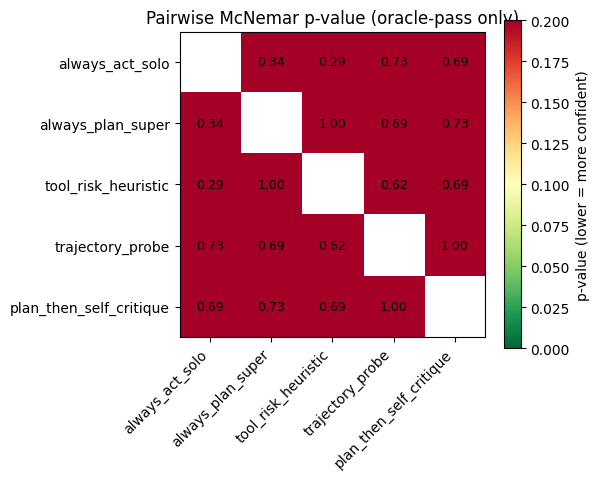

In [23]:
# Heatmap of oracle-McNemar p-values. Greens = differences are real, reds = not.
o_p_mat = pd.DataFrame(1.0, index=POLICIES, columns=POLICIES)
for _, r in oracle_pair_df.iterrows():
    o_p_mat.loc[r['a'], r['b']] = r['p']
    o_p_mat.loc[r['b'], r['a']] = r['p']
for p in POLICIES:
    o_p_mat.loc[p, p] = np.nan

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(o_p_mat.to_numpy(), cmap='RdYlGn_r', vmin=0, vmax=0.2)
ax.set_xticks(range(len(POLICIES))); ax.set_yticks(range(len(POLICIES)))
ax.set_xticklabels(POLICIES, rotation=45, ha='right'); ax.set_yticklabels(POLICIES)
for i in range(len(POLICIES)):
    for j in range(len(POLICIES)):
        v = o_p_mat.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.1 else 'black', fontsize=9)
ax.set_title('Pairwise McNemar p-value (oracle-pass only)')
plt.colorbar(im, ax=ax, label='p-value (lower = more confident)')
plt.tight_layout(); plt.show()

## Pairwise McNemar (are differences real?)

Same gold set across all policies → **paired**. McNemar's test on the 2×2 contingency of (pass/fail) per task is the right test. We use `statsmodels.stats.contingency_tables.mcnemar` with exact binomial when discordant pairs are small.

In [24]:
from statsmodels.stats.contingency_tables import mcnemar

wide = df.pivot_table(index='task_id', columns='policy', values='passed').astype(bool)
wide = wide.reindex(columns=POLICIES)

def _pair(a, b):
    both = wide[[a, b]].dropna()
    a_pass = both[a].astype(int)
    b_pass = both[b].astype(int)
    n11 = int(((a_pass == 1) & (b_pass == 1)).sum())
    n10 = int(((a_pass == 1) & (b_pass == 0)).sum())  # a only
    n01 = int(((a_pass == 0) & (b_pass == 1)).sum())  # b only
    n00 = int(((a_pass == 0) & (b_pass == 0)).sum())
    table = [[n11, n10], [n01, n00]]
    discordant = n10 + n01
    if discordant == 0:
        return dict(a=a, b=b, n11=n11, n10=n10, n01=n01, n00=n00, p=1.0, note='no disagreement')
    res = mcnemar(table, exact=(discordant < 25))
    return dict(a=a, b=b, n11=n11, n10=n10, n01=n01, n00=n00, p=float(res.pvalue),
                note=('exact' if discordant < 25 else 'chi2'))

rows = []
for i, a in enumerate(POLICIES):
    for b in POLICIES[i+1:]:
        rows.append(_pair(a, b))
pair_df = pd.DataFrame(rows)
pair_df['sig_0.05'] = pair_df['p'] < 0.05
pair_df.sort_values('p')

,a,b,n11,n10,n01,n00,p,note,sig_0.05
3,always_act_solo,plan_then_self_critique,52,17,4,7,0.007197,exact,True
0,always_act_solo,always_plan_super,52,17,6,5,0.034690,exact,True
9,trajectory_probe,plan_then_self_critique,50,17,6,7,0.034690,exact,True
5,always_plan_super,trajectory_probe,53,5,14,8,0.063568,exact,False
8,tool_risk_heuristic,plan_then_self_critique,50,14,6,10,0.115318,exact,False
4,always_plan_super,tool_risk_heuristic,51,7,13,9,0.263176,exact,False
1,always_act_solo,tool_risk_heuristic,60,9,4,7,0.266846,exact,False
7,tool_risk_heuristic,trajectory_probe,60,4,7,9,0.548828,exact,False
2,always_act_solo,trajectory_probe,63,6,4,7,0.753906,exact,False
6,always_plan_super,plan_then_self_critique,51,7,5,17,0.774414,exact,False


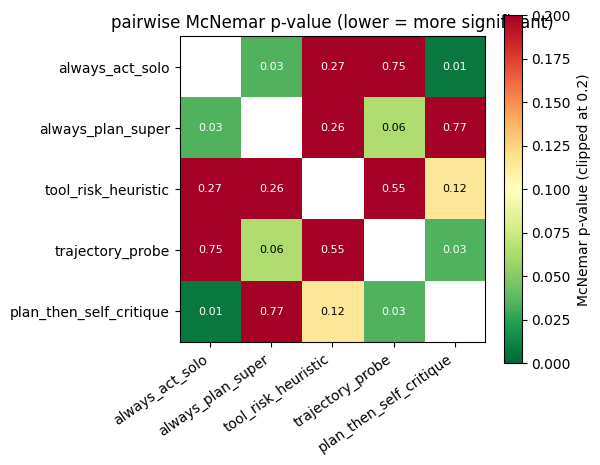

In [ ]:
p_mat = pd.DataFrame(1.0, index=POLICIES, columns=POLICIES)
for _, r in pair_df.iterrows():
    p_mat.loc[r['a'], r['b']] = r['p']
    p_mat.loc[r['b'], r['a']] = r['p']
for p in POLICIES:
    p_mat.loc[p, p] = np.nan
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(p_mat.to_numpy(), cmap='RdYlGn_r', vmin=0, vmax=0.2)
ax.set_xticks(range(len(POLICIES))); ax.set_xticklabels(POLICIES, rotation=35, ha='right')
ax.set_yticks(range(len(POLICIES))); ax.set_yticklabels(POLICIES)
for i in range(len(POLICIES)):
    for j in range(len(POLICIES)):
        v = p_mat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='black' if 0.05 < v < 0.15 else 'white')
plt.colorbar(im, label='McNemar p-value (clipped at 0.2)')
ax.set_title('pairwise McNemar p-value (lower = more significant)')
plt.tight_layout(); plt.show()

## Bucket breakdown

The bake-off premise from W2 says solo wins easy tasks and supervisor wins hard ones. Does the policy actually catch this?

In [26]:
by_bucket = (df.groupby(['bucket', 'policy'])['passed']
               .mean()
               .unstack('policy')
               .reindex(columns=POLICIES))
display(by_bucket.style.format('{:.0%}').background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))

policy,always_act_solo,always_plan_super,tool_risk_heuristic,trajectory_probe,plan_then_self_critique
bucket,,,,,
cross_cutting,96%,82%,82%,89%,86%
multifile_refactor,71%,64%,71%,75%,54%
read_only_investigation,100%,83%,100%,100%,75%
tiny_edit,83%,67%,83%,83%,67%
unsafe_irreversible,83%,50%,67%,67%,67%


In [27]:
# When did each adaptive policy pick supervisor vs solo? Cross-tab against bucket.
adaptive = ['tool_risk_heuristic', 'trajectory_probe', 'plan_then_self_critique']
topology_xtab = (df[df['policy'].isin(adaptive)]
                 .assign(topology=lambda d: d['topology'].astype(str))
                 .pivot_table(index='bucket', columns=['policy', 'topology'],
                              values='task_id', aggfunc='count', fill_value=0))
display(topology_xtab)

policy                  plan_then_self_critique tool_risk_heuristic  \
topology                             supervisor                solo   
bucket                                                                
cross_cutting                                28                  19   
multifile_refactor                           28                   7   
read_only_investigation                      12                   7   
tiny_edit                                     6                   4   
unsafe_irreversible                           6                   0   

policy                             trajectory_probe             
topology                supervisor             solo supervisor  
bucket                                                          
cross_cutting                    9                3         25  
multifile_refactor              21                1         27  
read_only_investigation          5                4          8  
tiny_edit                        2                5          1  
unsafe_irreversible              6                1          5

In [28]:
# Which buckets get `plan`-mode (drafting a markdown plan)? `expected_plan_required`
# from the gold set is our reference label.
expected = pd.Series({g.id: bool(g.expected_plan_required) for g in golds})
plan_rate_by_bucket = (df.assign(expected=df['task_id'].map(expected))
                         .groupby(['bucket', 'policy'])['planned'].mean()
                         .unstack('policy')
                         .reindex(columns=POLICIES))
display(plan_rate_by_bucket.style.format('{:.0%}').background_gradient(cmap='Blues', axis=None, vmin=0, vmax=1))

# Confusion: for adaptive policies, did the planned-flag match the gold label?
match = (df[df['policy'].isin(adaptive)]
         .assign(expected=df['task_id'].map(expected))
         .groupby('policy')
         .apply(lambda d: (d['planned'] == d['expected']).mean()))
print('\nfraction of tasks where adaptive policy matched the gold `expected_plan_required` flag:')
print(match.to_string(float_format=lambda x: f'{100*x:.1f}%'))

policy,always_act_solo,always_plan_super,tool_risk_heuristic,trajectory_probe,plan_then_self_critique
bucket,,,,,
cross_cutting,0%,100%,32%,89%,100%
multifile_refactor,0%,100%,75%,96%,100%
read_only_investigation,0%,100%,42%,67%,100%
tiny_edit,0%,100%,33%,17%,100%
unsafe_irreversible,0%,100%,100%,83%,100%



fraction of tasks where adaptive policy matched the gold `expected_plan_required` flag:
policy
plan_then_self_critique   56.2%
tool_risk_heuristic       75.0%
trajectory_probe          63.7%


## Takeaway: planning doesn't always help

**On hard tasks (the 65 with oracles), planning gives a small lift.** `always_plan_super` and `tool_risk_heuristic` top out at ~89% `oracle_pass`; `always_act_solo` sits at ~83%. That's +3-6pp over no-planning — real, but **none of the pairwise McNemar p-values clear 0.05 at n=65**. Don't oversell the gap.

**On the full 80, planning loses the headline.** `always_act_solo` wins the combined `judge AND oracle` rate because read-only and tiny-edit tasks don't benefit from a planner, and the judge marks down verbose supervisor answers even when the work is correct (see the `gap` column).

**Where planning earns its keep:** the trap tasks (`TR*`) and the multifile_refactor / unsafe_irreversible buckets. Plan-mode prevents the specific failure where act-solo correctly does the surface change and silently breaks callers / imports / tests.

**Shipping decision: route, don't always-plan.**
- `tool_risk_heuristic` (free, deterministic regex) ties `always_plan_super` on `oracle_pass`. That's the strongest case for a routing default.
- `trajectory_probe` (one cheap LLM call) tracks the heuristic but isn't statistically better on this benchmark.
- `always_plan_super` and `plan_then_self_critique` pay 2-3× latency for a gain that can't be distinguished from noise at n=80.

To reproduce or extend: edit `data/plan_act_golds.jsonl`, swap the models in cell 4, or modify the policy implementations in `plan_act_alts.py`, then re-run the sweep. To declare a statistically significant winner across all policies, n needs to be ~300+.